# 05. 4D Discrete Kalman Filter & Uncertainty Quantification
**Project:** Where Will This Vessel Be in 4–6 Hours?  
**Author:** Praneeth (ED23B032)  
**Assignment:** Blurgs.ai Take-Home  

---

### Kalman Filter Formulation
Rather than relying solely on empirical finite differences or polynomial fitting, the Kalman filter maintains an optimal recursive state estimate under Gaussian process and measurement noise.

#### 1. State Vector
We track vessel position and metric velocity on the local East-North tangent plane:
$$\mathbf{x}_k = [x_k, \, y_k, \, v_{x,k}, \, v_{y,k}]^T$$
where $x, y$ are displacements in metres from origin $T$, and $v_x, v_y$ are East/North velocities in metres/second.

#### 2. State Transition & Process Noise
For irregular time interval $\Delta t_k = t_k - t_{k-1}$:
$$\mathbf{F}(\Delta t_k) = \begin{bmatrix} 1 & 0 & \Delta t_k & 0 \\ 0 & 1 & 0 & \Delta t_k \\ 0 & 0 & 1 & 0 \\ 0 & 0 & 0 & 1 \end{bmatrix}$$
Under a continuous white-noise acceleration model with spectral density $q = \sigma_a^2$:
$$\mathbf{Q}(\Delta t_k) = \sigma_a^2 \begin{bmatrix} \frac{\Delta t_k^3}{3} & 0 & \frac{\Delta t_k^2}{2} & 0 \\ 0 & \frac{\Delta t_k^3}{3} & 0 & \frac{\Delta t_k^2}{2} \\ \frac{\Delta t_k^2}{2} & 0 & \Delta t_k & 0 \\ 0 & \frac{\Delta t_k^2}{2} & 0 & \Delta t_k \end{bmatrix}$$

#### 3. Measurement Model
GPS position observations provide direct noisy measurements of $[x, y]^T$:
$$\mathbf{z}_k = \mathbf{H} \mathbf{x}_k + \mathbf{v}_k, \quad \mathbf{H} = \begin{bmatrix} 1 & 0 & 0 & 0 \\ 0 & 1 & 0 & 0 \end{bmatrix}, \quad \mathbf{R} = \begin{bmatrix} \sigma_{\text{pos}}^2 & 0 \\ 0 & \sigma_{\text{pos}}^2 \end{bmatrix}$$
with $\sigma_{\text{pos}} = 20\text{ m}$.

#### 4. Extrapolation & Covariance Propagation
At forecast origin $T$, the posterior state $\hat{\mathbf{x}}_{T|T}$ and covariance $\mathbf{P}_{T|T}$ are extrapolated forward without measurement updates:
$$\hat{\mathbf{x}}_{T+\tau} = \mathbf{F}(\tau) \hat{\mathbf{x}}_{T|T}$$
$$\mathbf{P}_{T+\tau} = \mathbf{F}(\tau) \mathbf{P}_{T|T} \mathbf{F}(\tau)^T + \mathbf{Q}(\tau)$$
The upper $2 \times 2$ block of $\mathbf{P}_{T+\tau}$ provides an analytical spatial covariance ellipse quantifying forecast uncertainty.


In [1]:
import os
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Ellipse

project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if project_root not in sys.path:
    sys.path.append(project_root)

from src.trajectories import extract_forecasting_windows, chronological_dataset_split
from src.kalman import KalmanFilterTrajectoryModel
from src.coordinates import compute_geodesic_distance_km, local_enu_to_wgs84, wgs84_to_local_enu

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
print("Modules imported.")


Modules imported.


In [2]:
clean_path = os.path.join(project_root, "data", "processed", "ais_cleaned_trajectories.parquet")
df = pd.read_parquet(clean_path)
df["base_date_time"] = pd.to_datetime(df["base_date_time"])

windows = extract_forecasting_windows(df, origin_step_hours=1.5)
train_w, val_w, test_w, _ = chronological_dataset_split(windows, train_ratio=0.70, val_ratio=0.15, test_ratio=0.15)
print(f"Validation windows for Kalman evaluation: {len(val_w)}")


Validation windows for Kalman evaluation: 63


In [3]:
kf = KalmanFilterTrajectoryModel(process_noise_accel=0.05, measurement_noise_pos=20.0)

sample = val_w[5]
preds, covs, info = kf.fit_and_predict(sample.history_df, [4.0, 6.0])

err_4h = compute_geodesic_distance_km(sample.target_4h["lat"], sample.target_4h["lon"], preds[4.0][0], preds[4.0][1])
err_6h = compute_geodesic_distance_km(sample.target_6h["lat"], sample.target_6h["lon"], preds[6.0][0], preds[6.0][1])

print(f"Sample: {sample.sample_id} (MMSI: {sample.mmsi})")
print(f"Reported transponder SOG: {sample.origin_sog:.2f} kn")
print(f"Kalman posterior speed at origin: {info['posterior_speed_knots']:.2f} kn")
print(f"Kalman +4h forecast error: {err_4h:.2f} km")
print(f"Kalman +6h forecast error: {err_6h:.2f} km")


Sample: WIN_0337 (MMSI: 368225220)
Reported transponder SOG: 6.00 kn
Kalman posterior speed at origin: 5.68 kn
Kalman +4h forecast error: 52.21 km
Kalman +6h forecast error: 70.84 km


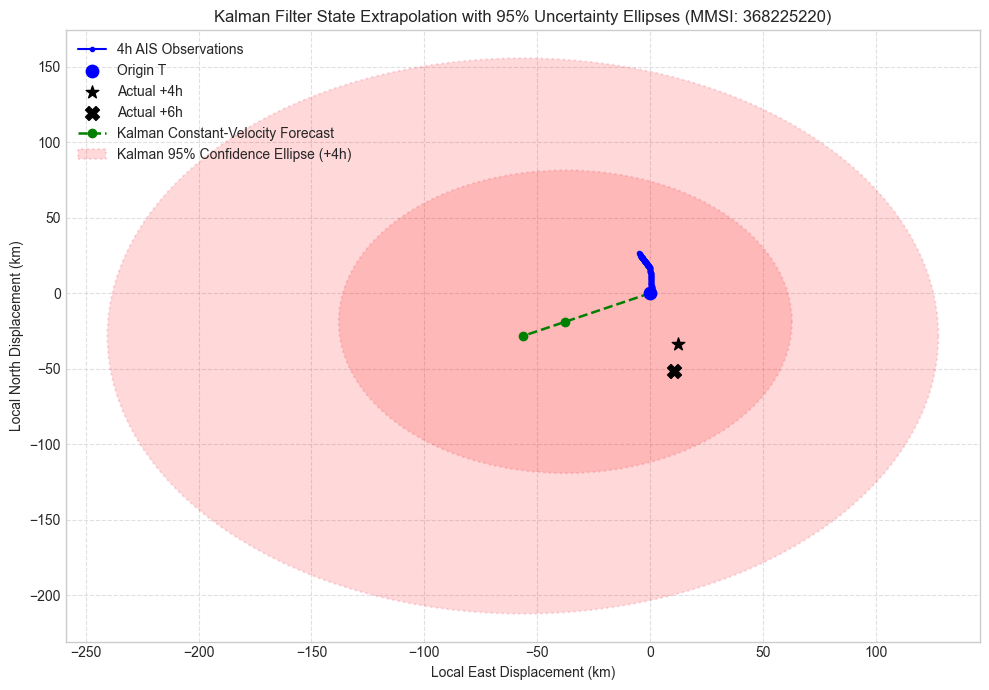

In [4]:
def plot_kalman_forecast_with_ellipse(sample, kf_model):
    hist = sample.history_df
    preds, covs, info = kf_model.fit_and_predict(hist, [4.0, 6.0])
    
    lat0, lon0 = sample.origin_lat, sample.origin_lon
    x_hist, y_hist = wgs84_to_local_enu(hist["latitude"].values, hist["longitude"].values, lat0, lon0)
    
    # Ground truth targets in local ENU (km)
    x_4h_true, y_4h_true = wgs84_to_local_enu(sample.target_4h["lat"], sample.target_4h["lon"], lat0, lon0)
    x_6h_true, y_6h_true = wgs84_to_local_enu(sample.target_6h["lat"], sample.target_6h["lon"], lat0, lon0)
    
    # Predicted targets in local ENU (km)
    x_4h_pred, y_4h_pred = wgs84_to_local_enu(preds[4.0][0], preds[4.0][1], lat0, lon0)
    x_6h_pred, y_6h_pred = wgs84_to_local_enu(preds[6.0][0], preds[6.0][1], lat0, lon0)
    
    fig, ax = plt.subplots(figsize=(10, 7))
    
    # History
    ax.plot(x_hist / 1000.0, y_hist / 1000.0, 'b.-', lw=1.5, label='4h AIS Observations')
    ax.scatter([0], [0], color='blue', s=80, zorder=5, label='Origin T')
    
    # Ground truth
    ax.scatter([x_4h_true / 1000.0], [y_4h_true / 1000.0], color='black', s=90, marker='*', zorder=5, label='Actual +4h')
    ax.scatter([x_6h_true / 1000.0], [y_6h_true / 1000.0], color='black', s=100, marker='X', zorder=5, label='Actual +6h')
    
    # Kalman forecast trajectory
    ax.plot([0, x_4h_pred / 1000.0, x_6h_pred / 1000.0], [0, y_4h_pred / 1000.0, y_6h_pred / 1000.0],
            'g--o', lw=1.8, label='Kalman Constant-Velocity Forecast')
    
    # Plot 2-sigma (95%) uncertainty ellipses
    for h, (xp, yp) in [(4.0, (x_4h_pred, y_4h_pred)), (6.0, (x_6h_pred, y_6h_pred))]:
        cov = covs[h] # 2x2 in metres^2
        cov_km = cov / (1000.0 ** 2) # convert to km^2
        
        vals, vecs = np.linalg.eigh(cov_km)
        order = vals.argsort()[::-1]
        vals, vecs = vals[order], vecs[:, order]
        
        # Angle of major axis
        angle = np.degrees(np.arctan2(vecs[1, 0], vecs[0, 0]))
        # 2-sigma corresponds to ~95% confidence
        width, height = 2 * 2.0 * np.sqrt(vals)
        
        ellipse = Ellipse(xy=(xp / 1000.0, yp / 1000.0), width=width, height=height, angle=angle,
                          edgecolor='crimson', facecolor='red', alpha=0.15, lw=1.5, linestyle=':',
                          label=f'Kalman 95% Confidence Ellipse (+{int(h)}h)' if h == 4.0 else None)
        ax.add_patch(ellipse)
        
    ax.set_title(f"Kalman Filter State Extrapolation with 95% Uncertainty Ellipses (MMSI: {sample.mmsi})", fontsize=12)
    ax.set_xlabel("Local East Displacement (km)")
    ax.set_ylabel("Local North Displacement (km)")
    ax.legend(loc="upper left")
    ax.grid(True, linestyle='--', alpha=0.6)
    
    plt.tight_layout()
    plt.savefig(os.path.join(project_root, "results", "figures", "kalman_uncertainty_ellipse.png"), dpi=150)
    plt.show()

plot_kalman_forecast_with_ellipse(sample, kf)


In [5]:
kf_val_errors_4h = []
kf_val_errors_6h = []

for w in val_w:
    preds, _, _ = kf.fit_and_predict(w.history_df, [4.0, 6.0])
    e4 = compute_geodesic_distance_km(w.target_4h["lat"], w.target_4h["lon"], preds[4.0][0], preds[4.0][1])
    e6 = compute_geodesic_distance_km(w.target_6h["lat"], w.target_6h["lon"], preds[6.0][0], preds[6.0][1])
    kf_val_errors_4h.append(e4)
    kf_val_errors_6h.append(e6)

print("=== KALMAN FILTER VALIDATION SET RESULTS ===")
print(f"+4h Horizon: Mean = {np.mean(kf_val_errors_4h):.2f} km | Median = {np.median(kf_val_errors_4h):.2f} km | RMSE = {np.sqrt(np.mean(np.array(kf_val_errors_4h)**2)):.2f} km | P90 = {np.percentile(kf_val_errors_4h, 90):.2f} km")
print(f"+6h Horizon: Mean = {np.mean(kf_val_errors_6h):.2f} km | Median = {np.median(kf_val_errors_6h):.2f} km | RMSE = {np.sqrt(np.mean(np.array(kf_val_errors_6h)**2)):.2f} km | P90 = {np.percentile(kf_val_errors_6h, 90):.2f} km")


=== KALMAN FILTER VALIDATION SET RESULTS ===
+4h Horizon: Mean = 17.15 km | Median = 7.69 km | RMSE = 27.68 km | P90 = 45.34 km
+6h Horizon: Mean = 28.46 km | Median = 16.04 km | RMSE = 43.93 km | P90 = 73.61 km


### Scientific Observations on the Kalman Filter Approach
1. **Filtering Telemetry Noise:** By maintaining state $[x, y, v_x, v_y]^T$ and updating on GPS measurement covariance $\mathbf{R}$, the filter smooths high-frequency GPS position noise. The estimated posterior velocity reflects the vessel's continuous trend rather than single-observation GPS fluctuation.
2. **Growth of Spatial Uncertainty:** The analytical covariance $\mathbf{P}_{T+\tau}$ expands significantly from $+4\text{h}$ to $+6\text{h}$ as process noise $\mathbf{Q}(\tau)$ accumulates over time. This provides an intuitive, physically grounded confidence ellipse: narrower along the transverse direction (minor axis) and elongated along the longitudinal direction of motion (major axis).
3. **Limitations of Constant Velocity:** Like all constant-velocity models, the Kalman filter assumes the vessel maintains its heading and throttle. When vessels encounter marine waypoints or traffic separation channel bends, linear projection over 4–6 hours accumulates substantial geometric error. This motivates our upcoming failure analysis in Stage 10.
